<b><h1><center>Merging Joining & Concatenating</center></h1></b>






**We will solve a lot of question and you will comfortable with these all concepts**

In [1]:
# importing the libraries
import numpy as np
import pandas as pd

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
# loading dataset
students = pd.read_excel("data/20_data/students.xlsx")
courses = pd.read_csv("data/20_data/courses.csv")
nov = pd.read_csv("data/20_data/reg-month1.csv")
dec = pd.read_csv("data/20_data/reg-month2.csv")
match = pd.read_csv("data/20_data/matches.csv")
ipl = pd.read_csv("data/20_data/deliveries.csv")

# **Concatenation**
**The word Concatenate means:**

To join multiple things together in sequence.

<br>

# **concat()**

pd.concat() is a method which combines two or more Pandas objects (Series or DataFrames) along a particular axis.

**In simple words,**

It simply sticks objects together.



**syntax:**

pd.concat(
    objs,
    axis=0,
    join="outer",
    ignore_index=False,
    keys=None,
    levels=None,
    names=None,
    verify_integrity=False,
    sort=False,
    copy=None
)


# **Parameters:**

| Parameter          | Default   | Accepted Values                    | Purpose                         | Explanation                                                         |
| ------------------ | --------- | ---------------------------------- | ------------------------------- | ------------------------------------------------------------------- |
| `objs`             | Required  | List/Tuple of Series or DataFrames | Objects to concatenate          | This is the only required parameter.                                |
| `axis`             | `0`       | `0`, `1`, `"index"`, `"columns"`   | Direction of concatenation      | `0` = stack vertically (rows). `1` = join horizontally (columns).   |
| `join`             | `"outer"` | `"outer"`, `"inner"`               | Handle mismatched labels        | `"outer"` keeps all labels. `"inner"` keeps only common labels.     |
| `ignore_index`     | `False`   | `True`, `False`                    | Reset index after concatenation | `True` creates a new index 0,1,2...                                 |
| `keys`             | `None`    | List                               | Create hierarchical index       | Adds labels identifying where each object came from.                |
| `verify_integrity` | `False`   | `True`, `False`                    | Check duplicate indexes         | Raises an error if duplicate index labels are created.              |
| `sort`             | `False`   | `True`, `False`                    | Sort labels                     | Mostly affects column order when labels differ.                     |
| `copy`             | `None`    | `True`, `False`, `None`            | Copy underlying data            | Controls whether Pandas tries to avoid copying data where possible. |


In [86]:
# side by side concatenation
a = pd.concat([nov, dec], axis=1)

In [ ]:
# giving columns name 
b = pd.concat([nov, dec], axis=1, keys=["nov", "dec"])

In [ ]:

c = pd.concat([nov, dec])

In [91]:
register = pd.concat([nov, dec], keys=["nov", "dec"])

In [82]:
reg_without_in = pd.concat([nov, dec], ignore_index=True)

<br>

# **Merging**
The process in which we combine two dataframe on the bases of common column.


<br>

### **merge()**

merge() is used to combine two DataFrames by matching common values between them.


| **Parameter**     | **Default**   | **Accepted Values**                                  | **Purpose**                 | **Explanation**                                                                                                                                                   |
| ----------------- | ------------- | ---------------------------------------------------- | --------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`left`**        | Required      | DataFrame                                            | Left DataFrame              | The first DataFrame in the merge. Pandas starts from this DataFrame.                                                                                              |
| **`right`**       | Required      | DataFrame                                            | Right DataFrame             | The second DataFrame whose rows will be matched with the left DataFrame.                                                                                          |
| **`how`**         | `"inner"`     | `"inner"`, `"left"`, `"right"`, `"outer"`, `"cross"` | Type of merge               | Determines which rows are kept after matching. This is the most important parameter and deserves a separate lesson.                                               |
| **`on`**          | `None`        | String or List                                       | Common key(s)               | Column(s) that exist in **both** DataFrames and should be used for matching.                                                                                      |
| **`left_on`**     | `None`        | String or List                                       | Left merge key              | Specifies the matching column(s) in the left DataFrame when the column names differ.                                                                              |
| **`right_on`**    | `None`        | String or List                                       | Right merge key             | Specifies the matching column(s) in the right DataFrame when the column names differ.                                                                             |
| **`left_index`**  | `False`       | `True`, `False`                                      | Use left index              | Instead of using a column, use the **index** of the left DataFrame as the merge key.                                                                              |
| **`right_index`** | `False`       | `True`, `False`                                      | Use right index             | Instead of using a column, use the **index** of the right DataFrame as the merge key.                                                                             |
| **`sort`**        | `False`       | `True`, `False`                                      | Sort output                 | Whether to sort the merge keys in the final DataFrame.                                                                                                            |
| **`suffixes`**    | `("_x","_y")` | Tuple of two strings                                 | Rename duplicate columns    | Appends suffixes to overlapping non-key column names to avoid conflicts.                                                                                          |
| **`copy`**        | `None`        | `True`, `False`, `None`                              | Copy data                   | Controls whether Pandas tries to avoid unnecessary copies of the data. In everyday use, you can usually ignore this parameter.                                    |
| **`indicator`**   | `False`       | `True`, `False` or String                            | Merge source information    | Adds a column showing whether each row came from the left DataFrame, the right DataFrame, or both.                                                                |
| **`validate`**    | `None`        | `"1:1"`, `"1:m"`, `"m:1"`, `"m:m"`                   | Validate merge relationship | Checks whether the merge follows the expected one-to-one, one-to-many, many-to-one, or many-to-many relationship. Raises an error if the expectation is violated. |


In [108]:
# using common columns having same name in both dataframe
rc = pd.merge(register, courses, on="course_id", how="inner")

In [118]:
# using common columns having different name in both dataframe
im = pd.merge(ipl, match, left_on="match_id", right_on="id")

In [128]:
# using index from one dataframe and columns from another dataframe
r = register.set_index('student_id')

rs = pd.merge(r, students, left_index=True, right_on="student_id")

# **Joining ways**

| Join Type | Keeps Left Rows | Keeps Right Rows | Keeps Only Matches |             Missing Values Filled with `NaN` |
| --------- | --------------: | ---------------: | -----------------: | -------------------------------------------: |
| **Inner** |  ❌ Only matched |   ❌ Only matched |              ✅ Yes | Rarely (only in special duplicate-key cases) |
| **Left**  |           ✅ Yes |   ✅ Only matched |                  ❌ |           Yes, for missing right-side values |
| **Right** |  ✅ Only matched |            ✅ Yes |                  ❌ |            Yes, for missing left-side values |
| **Outer** |           ✅ Yes |            ✅ Yes |                  ❌ |          Yes, on whichever side has no match |


### **We will use these all concept in below questions and you will understand it**

# **Some Question related to merging $ concatenating**

### **1. find total revenue generated**

In [6]:
reg = pd.concat([nov, dec], keys=["nov", "dec"]).merge(courses, how='inner', on='course_id')["price"].sum()
str(reg)


'154247'

### **2. find month by month revenue**

In [7]:
pd.concat([nov, dec], keys=["nov", "dec"]).reset_index(level=0).merge(courses, how='inner', on='course_id').groupby("level_0")["price"].sum()


level_0
dec    65072
nov    89175
Name: price, dtype: int64

### **3. Print the registration table**
cols -> name -> course -> price

In [8]:
registration = pd.concat([nov, dec], keys=["nov", "dec"]).reset_index(level=0).merge(courses, how='inner', on='course_id').merge(students, how='inner', on="student_id")
registration[["name", "course_name", "price"]]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


### **4. Plot bar chart for revenue/course**

<Axes: xlabel='course_name'>

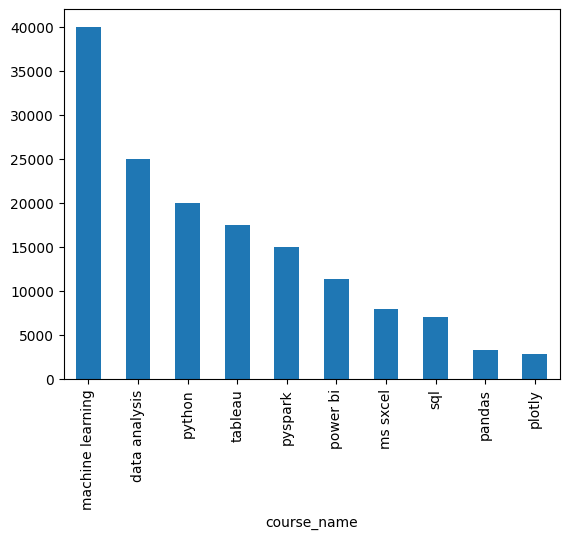

In [9]:
registration.groupby("course_name")["price"].sum().sort_values(ascending=False).plot(kind='bar')

### **5. find students who enrolled in both the months**

In [10]:
s = np.intersect1d(nov["student_id"], dec["student_id"])

students[students["student_id"].isin(s)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


### **6. find course that got no enrollment**

In [11]:
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [12]:
reg = pd.concat([nov, dec], keys=["nov", "dec"]).merge(courses, how='inner', on='course_id')
i = np.setdiff1d(courses["course_id"], reg["course_id"])
courses[courses["course_id"].isin(i)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


### **7. find students who did not enroll into any courses**

In [ ]:
st = np.setdiff1d(students["student_id"], reg["student_id"])
students[students["student_id"].isin(st)]

,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11


### **8. Print student name -> partner name for all enrolled students**

In [73]:
# this is actually an example of self join
students.merge(students, left_on='partner', right_on="student_id").rename(columns={"name_x":"Student", "name_y":"Partner"})[["Student", "Partner"]]

,Student,Partner
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


### **9. find top 3 students who did most number enrollments**

In [15]:
top = reg["student_id"].value_counts().sort_values(ascending=False).head(3)
s = students[students["student_id"].isin(list(top.index))]["name"]

d = pd.DataFrame()
d["name"] = s.values
d["repeation"]= top.values
d

,name,repeation
0,Tarun Thaker,6
1,Elias Dodiya,5
2,Chhavi Lachman,4


### **10. find top 3 students who spent most amount of money on courses**

In [16]:
students.merge(reg, on="student_id").groupby(["student_id", "name"])["price"].sum().sort_values(ascending=False).head(3).reset_index(level=0, drop=True)

name
Chhavi Lachman      22594
Pranab Natarajan    15096
Qabeel Raman        13498
Name: price, dtype: int64

### **find top 3 studiums with highest sixes/match ratio**

In [17]:
pd.options.display.max_columns = None
df = pd.merge(ipl, match, left_on="match_id", right_on="id")
sixes = df[df["batsman_runs"]==6]
sixes_count = sixes.groupby('venue')["venue"].count()
total_matches = match["venue"].value_counts()
(sixes_count/total_matches).sort_values(ascending=False).head(3)

venue
Holkar Cricket Stadium     17.600000
M Chinnaswamy Stadium      13.227273
Sharjah Cricket Stadium    12.666667
dtype: float64

<br>

---